# Ablation Row 2 — + Extra features

| | Value |
|---|---|
| Features | **full** (spatial + colour hist + LBP + intensity + HOG fine + HOG coarse, ~32801-d) |
| PCA | 4677 components (90% variance) |
| Scales | (1.0,) — single scale |
| HNM | off |
| Threshold | `cfg.detection_threshold = 1.5` (default) |

Delta vs row 1: turn on the full feature vector. Same detection/threshold setup.

Artifacts → `microglia-artifacts-row2/`. Row 3 will load these pkls and re-run
inference with the multi-scale pyramid.

## 1  Imports + Config

In [1]:
import os
import joblib
import numpy as np
import matplotlib.image as mpimg

from pipeline import (
    Config,
    extract_raw_features, fit_pipeline,
    tune_svm, train_svm, evaluate_classifier,
    process_image, multi_scale_detect, non_max_suppression,
    load_gt_boxes, evaluate_detections, plot_gt_vs_pred,
    save_hard_negatives, tune_detection_threshold,
    ensure_test_patches, patch_level_test_eval, detection_level_test_eval,
    extract_features, list_images,
)

%matplotlib inline

In [2]:
cfg = Config(
    artifact_dir='./microglia-artifacts-row2',
    feature_mode='full',
    scale_factors=(1.0,),
    pca_n_components=4677,
    detection_threshold=1.5,
)
os.makedirs(cfg.artifact_dir, exist_ok=True)
print(cfg)

Config(image_rois_csv='../Image_ROIs.csv', source_images='../Source_images', test_dir='../test_images', microglia_folder='./Processed_training_images/Train/Microglia', noise_folder='./Processed_training_images/Train/Noise', microglia_val_folder='./Processed_training_images/Validate/Microglia', noise_val_folder='./Processed_training_images/Validate/Noise', microglia_test_folder='./Processed_training_images/Test/Microglia', noise_test_folder='./Processed_training_images/Test/Noise', hnm_folder='./Processed_training_images/HardNegatives', artifact_dir='./microglia-artifacts-row2', features_cache='./microglia-artifacts-row2/features_cache.npz', svm_clf_path='./microglia-artifacts-row2/svm_clf.pkl', scaler_path='./microglia-artifacts-row2/scaler.pkl', pca_path='./microglia-artifacts-row2/pca.pkl', val_paths_cache='./microglia-artifacts-row2/val_paths.txt', hnm_train_final='./microglia-artifacts-row2/hnm_train_final.npz', image_size=2048, window_size=64, feature_mode='full', scale_factors=(1

## 2  Train (full features → PCA → tune C → fit SVM)

In [3]:
X_train_raw, X_val_raw, y_train_raw, y_val_raw = extract_raw_features(cfg)
np.savez_compressed(cfg.features_cache,
                    X_train_raw=X_train_raw, X_val_raw=X_val_raw,
                    y_train_raw=y_train_raw, y_val_raw=y_val_raw)

X_train, X_val, y_train, y_val, scaler, pca = fit_pipeline(
    X_train_raw, X_val_raw, y_train_raw, y_val_raw, cfg
)

best_params = tune_svm(X_train, y_train, cfg)
svm_clf = train_svm(X_train, y_train, cfg)

joblib.dump(svm_clf, cfg.svm_clf_path)
joblib.dump(scaler,  cfg.scaler_path)
joblib.dump(pca,     cfg.pca_path)
print(f"Saved artifacts → {cfg.artifact_dir}/")

print("\nValidate patch-level metrics:")
evaluate_classifier(svm_clf, X_val, y_val, label='val')

Train    — microglia: 5304, noise: 9610
Validate — microglia: 153,  noise: 2883

Extracting train features...


  [train microglia] 5304/5304 (100%) — 5304 feature vectors extracted


  [train noise] 9610/9610 (100%) — 9610 feature vectors extracted
Extracting validate features...


  [val microglia] 153/153 (100%) — 153 feature vectors extracted


  [val noise] 2883/2883 (100%) — 2883 feature vectors extracted



Raw feature dim : 32801
Train: 14914 | Validate: 3036


PCA: 32801 → 4677 components (89.8% variance retained)
Train: 14914 | Validate: 3036
Fitting 5 folds for each of 6 candidates, totalling 30 fits



C        mean-F1  std-F1
0.001    0.9530   ±0.0046
0.01     0.9547   ±0.0045 ← best
0.1      0.9541   ±0.0049
1.0      0.9543   ±0.0049
10.0     0.9542   ±0.0049
100.0    0.9542   ±0.0049

Best params : {'C': 0.01}
Best CV F1  : 0.9547


Training time : 11.06s


Saved artifacts → ./microglia-artifacts-row2/

Validate patch-level metrics:
[val] Accuracy  : 0.9687
[val] Precision : 0.6229
[val] Recall    : 0.9608
[val] F1-Score  : 0.7558


## 3  Held-out test evaluation

── Patch-level test ──


  [test microglia] 245/245 (100%) — 245 feature vectors extracted


  [test noise] 1922/1922 (100%) — 1922 feature vectors extracted


[test] Accuracy  : 0.6530
[test] Precision : 0.2457
[test] Recall    : 1.0000
[test] F1-Score  : 0.3945

── Detection-level test (single scale, t=1.50) ──
Running detection on 2 test images at scales (1.0,), threshold=1.50

── 13_s46 ──
  scale=1.00 (2048×2048px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


...

     67% 

     77% 

     87% 

     96% 

100%
  → 1654 candidates at this scale
  Total candidates : 1654
  After NMS        : 507
  Detection time: 60.7s
  GT=123  Pred=507  TP=40  FP=467  FN=83  P=0.079  R=0.325


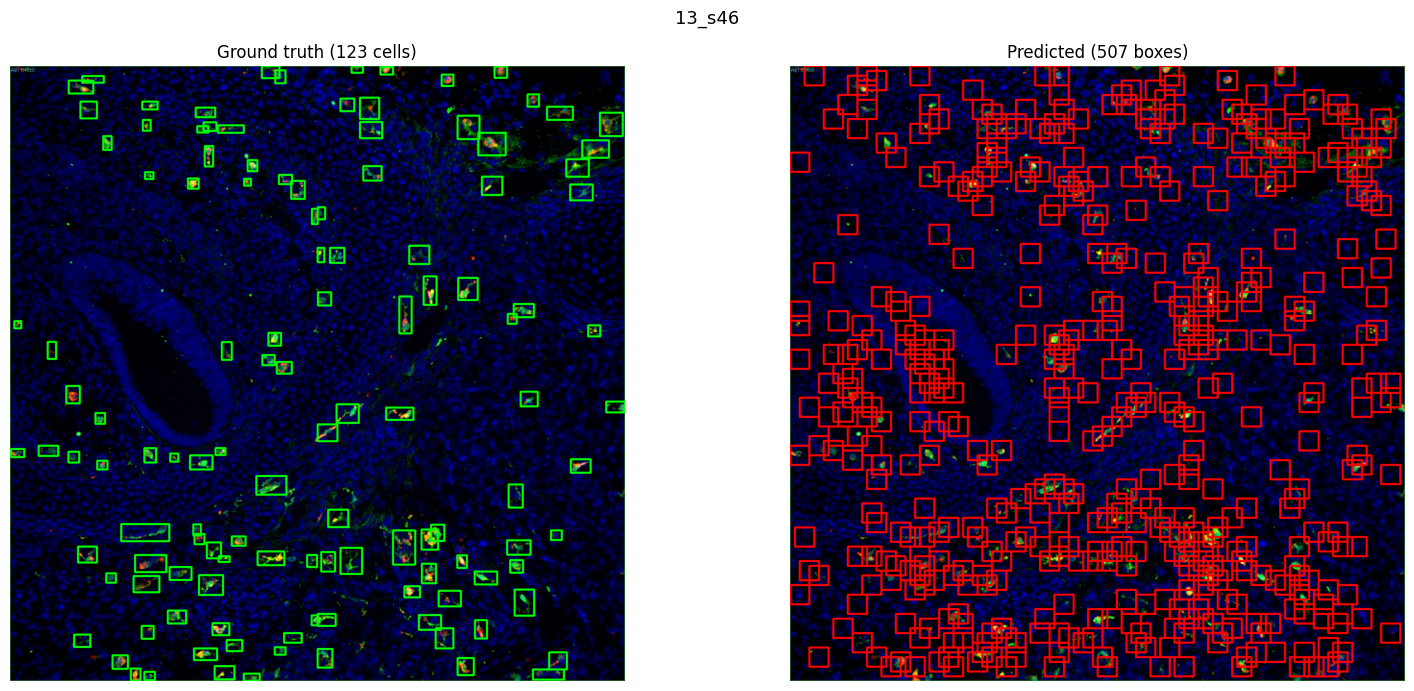


── 14_s47 ──
  scale=1.00 (2048×2048px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0% 

      9% 

     19% 

...

     67% 

     77% 

     87% 

     96% 

100%
  → 1920 candidates at this scale
  Total candidates : 1920
  After NMS        : 592
  Detection time: 62.8s
  GT=122  Pred=592  TP=51  FP=541  FN=71  P=0.086  R=0.418


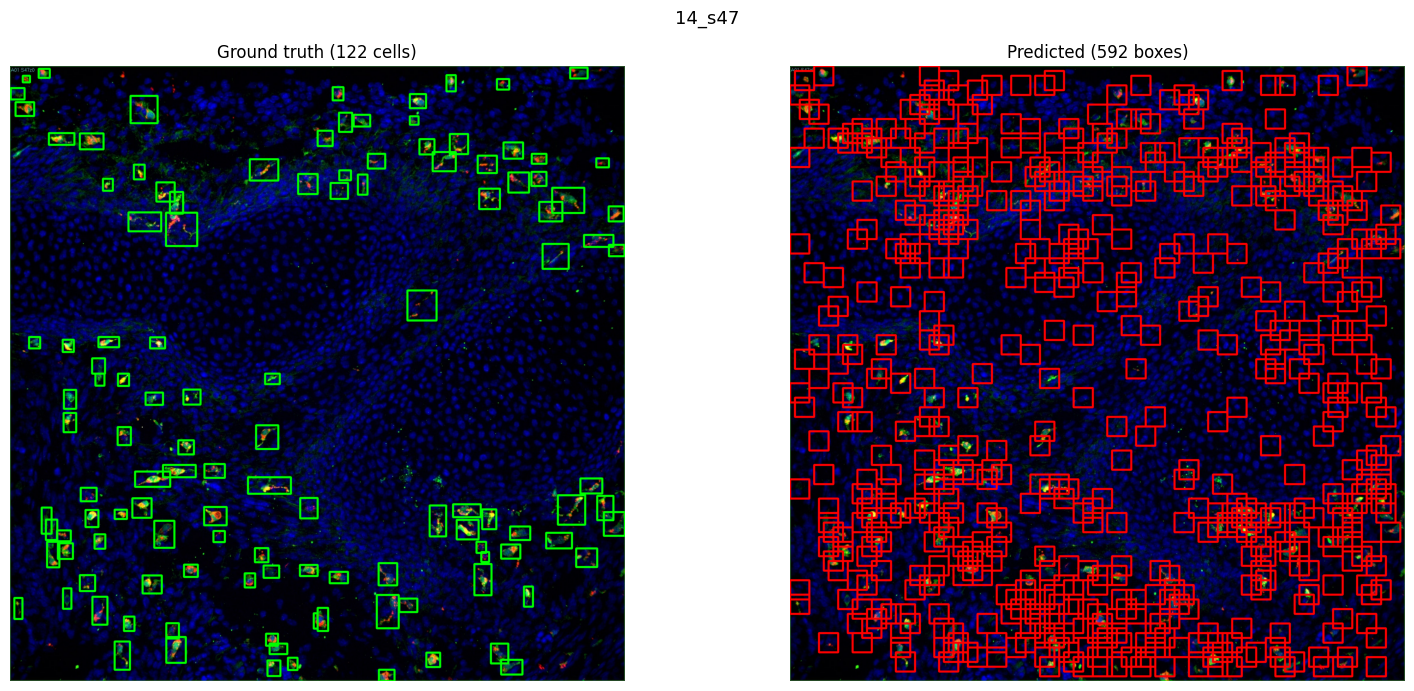


== AGGREGATE  TP=91  FP=1008  FN=154
   Precision=0.083  Recall=0.371  F1=0.135


In [4]:
ensure_test_patches(cfg)

print("── Patch-level test ──")
patch_level_test_eval(svm_clf, scaler, pca, cfg)

print("\n── Detection-level test (single scale, t=%.2f) ──" % cfg.detection_threshold)
row2_metrics = detection_level_test_eval(svm_clf, scaler, pca, cfg, show_plots=True)